**Задание 1**

Известно, что $g(x) = 2^x + 1$. Вычислите численное значение $g(g(2))$.

In [80]:
from sympy import Matrix, symbols, solve, Eq, init_printing, UnevaluatedExpr, Pow, latex, Lambda
from IPython.display import display, Math

init_printing()

x = symbols("x")
x_i = 2
g = Lambda(x, Pow(2, x) + 1)

display(Math(f"""
    Дана \\ исходная \\ функция: \\ g(x) = {latex(g(x))} \\\\[1em]
    Требуется \\ сделать \\ расчет \\ функции \\ вида \\ g(g(x)) = {latex(g(g(x)))} \\\\[1em]
    Для \\ начала \\ расчитаем \\ g({x_i}), \\ подставив \\ x = {x_i} \\Rightarrow g({x_i}) = {latex(g(x))} = 2^{x_i} + 1 = {g(x_i)} \\\\[1em]
    Теперь \\ полученное \\ значение \\ {g(x_i)} \\ подставим \\ еще \\ раз, \\ получим \\ g(g({x_i})) = 2^{g(x_i)} + 1 = {g(g(x_i))}
"""))


<IPython.core.display.Math object>

**Задание 2**

Даны матрицы:

$$
A = \begin{pmatrix}
2 & -4 \\
3 & 5 \\
-1 & 0
\end{pmatrix}, \quad
B = \begin{pmatrix}
1 & 2 & 7 \\
-3 & -4 & 0 \\
5 & 2 & 1
\end{pmatrix}, \quad
C = \begin{pmatrix}
6 & -3 & 9 \\
4 & -5 & 2 \\
8 & 1 & 5
\end{pmatrix}.
$$

Посчитайте матрицу $D = A^T C - 2A^T B^T $.  
Приведите полную последовательность вычислений.

*Желательно оформить решение прямо в ноутбуке в текстовой ячейке, используя [latex-markdown](https://colab.research.google.com/notebooks/markdown_guide.ipynb).*

**Задание 2 решено в ноутбуке homework_08 в блоке Линейная алгебра под номером 1-1.**

**Задание 3**

Дано выражение:

$$
3 \cdot \begin{pmatrix}
x & 2 & 3 \\
-1 & y & 4
\end{pmatrix}
+ 2 \cdot \begin{pmatrix}
1 & 2 & -5 \\
2 & -6 & z
\end{pmatrix}
= \begin{pmatrix}
8 & v & -1 \\
1 & 6 & 4
\end{pmatrix}.
$$

Найдите значения $(x, y, z)$ и $v$, при которых выражение верно.

**Задание 3 решено в ноутбуке homework_08 в блоке Линейная алгебра под номером 1-2.**

**Задание 4-5**

На координатной плоскости отмечено 3 точки:

<img src="https://github.com/dmi3eva/resources/blob/main/2026-04-27_OLS-home.png?raw=true" width="500">

**Цель:**

Найти прямую, проходящую через (0, 0), для которой минимальна:

3) Сумма отклонений от данных точек по `у`

4) Сумма квадратов отклонений от данных точек по `у`


**Пример:**

Для данной синей прямой, суммарное отклонение по `y` составляет 5 + 0 + 8 = 13.

<img src="https://github.com/dmi3eva/resources/blob/main/2026-04-27_OLS-example.png?raw=true" width="500">



**Задание:**

Для каждого из пунктов опишите следующие шаги своего решения:

* **Шаг 1.** Введите и опишите параметры, которые могут задавать прямую. Постарайтесь, чтобы их было как можно меньше.

* **Шаг 2.** Запишите целевую функцию, зависящую от этих параметров.

* **Шаг 3.** Подберите параметры, при которых достигается минимальное значение данной целевой функции. Вы можете использовать производные или графический метод (например, с использованием сервиса https://www.geogebra.org). Важно найти именно точное решение.

* **Шаг 4.** Нарисуйте хотя бы одну прямую, соответствующую найденным параметрам. Рисунок можно нарисовать, используя графические библиотеки или https://www.geogebra.org. Также вы можете просто вставить фото своего чертежа.

МНК y = kx: k = -17/38
МНМ y = kx: k = -3/5
МНК y = kx + b: k = -55/98, b = 53/49
Графическое решение:
https://www.geogebra.org/m/qmthtrcy
https://www.geogebra.org/m/e9rj235z
https://www.geogebra.org/m/tyw8kahu


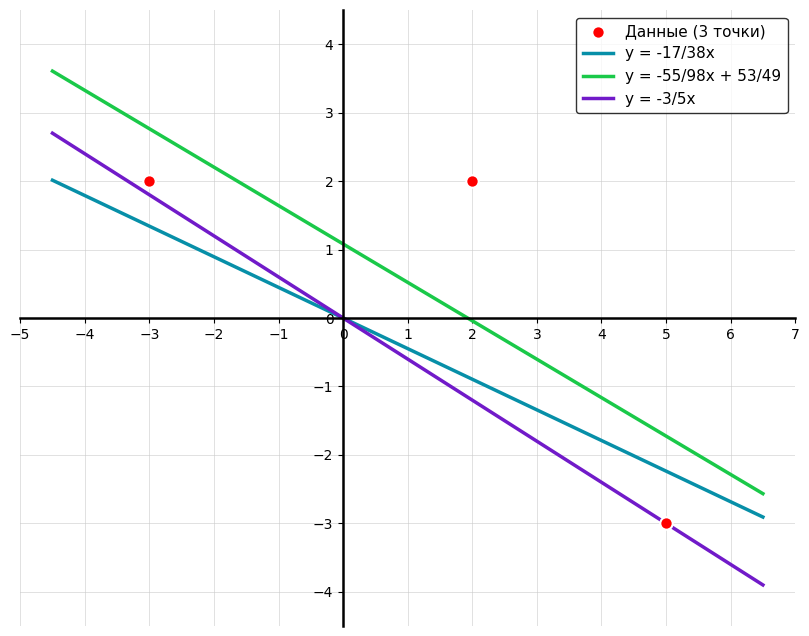

In [210]:
from sympy import symbols, diff, solve, Lambda, Eq, Subs
import matplotlib.pyplot as plt
import numpy as np

x = np.array([-3, 2, 5])
y = np.array([2, 2, -3])

k, b = symbols("k b")

def least_squares(f, x, y):
    S = sum((y_i - f(x_i))**2 for x_i, y_i in zip(x, y))

    gradient = [diff(S, coef) for coef in S.free_symbols]
    solution = solve(gradient, S.free_symbols)

    return [solution[coef] for coef in S.free_symbols] if len(solution) > 1 \
        else solution[next(iter(S.free_symbols))]

def least_modules(f, x, y):
    L = sum(abs(y_i - f(x_i)) for x_i, y_i in zip(x, y))

    k_points = {}
    for x_i, y_i in zip(x, y):
        point, = solve(Eq((y_i - f(x_i)), 0), L.free_symbols)

        k_points[L.subs(L.free_symbols, point)] = point 
        
    return k_points[min(k_points)]



f = lambda x: k * x
g = lambda x: k * x + b

k1 = least_squares(f, x, y)
k3 = least_modules(f, x, y)

k2, b2 = least_squares(g, x, y)


print(f"МНК y = kx: k = {k1}")
print(f"МНМ y = kx: k = {k3}")
print(f"МНК y = kx + b: k = {k2}, b = {b2}")

print("Графическое решение:", 
      "https://www.geogebra.org/m/qmthtrcy", 
      "https://www.geogebra.org/m/e9rj235z", 
      "https://www.geogebra.org/m/tyw8kahu", sep='\n')


x_min, x_max = min(x) - 1.5, max(x) + 1.5
x_plot = np.linspace(x_min, x_max, 400)

y1_plot = k1 * x_plot
y2_plot = k2 * x_plot + b2
y3_plot = k3 * x_plot

plt.figure(figsize=(10, 8))
ax = plt.gca()

plt.scatter(x, y, color='red', s=80, edgecolors='white', linewidths=1.5, zorder=5, label='Данные (3 точки)')

plt.plot(x_plot, y1_plot, color="#078FA8", linewidth=2.5, label=f'y = {k1}x')
plt.plot(x_plot, y2_plot, color="#1AC949", linewidth=2.5, label=f'y = {k2}x + {b2}')
plt.plot(x_plot, y3_plot, color="#711AC9", linewidth=2.5, label=f'y = {k3}x')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.8)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')

xticks = np.arange(int(np.floor(x_min)), int(np.ceil(x_max)) + 1, 1)
yticks = np.arange(int(np.floor(-4)), int(np.ceil(4)) + 1, 1)
ax.set_xticks(xticks)
ax.set_yticks(yticks)

plt.grid(True, which='major', linestyle='-', linewidth=0.7, color='#CCCCCC', alpha=0.6, zorder=0)
plt.legend(loc='best', frameon=True, edgecolor='black', fontsize=11)

plt.xlim(x_min - 0.5, x_max + 0.5)
plt.ylim(-4.5, 4.5)

plt.show()


**Задание 6**

* Запишите матрично-векторное уравнение $Ax = b$ в виде системы линейных уравнений.

* Решите его любым способом, найдя **вектор** $x$. Решение опишите.



$$
A =
 \begin{pmatrix}
  1 & 2 & 4 \\
  2 & 1 & -1 \\
  1 & -1 & 1 \\
 \end{pmatrix}
 $$

 $$
 b =
  \begin{pmatrix}
  3 \\
  -9 \\
  0 \\
 \end{pmatrix}
 $$

In [203]:
import numpy as np
from fractions import Fraction
from sympy import latex, Matrix
from IPython.display import Math, display

A = Matrix([[1, 2, 4],
            [2, 1, -1],
            [1, -1, 1]])

b = Matrix([3, -9, 0])

detA = A.det()
C = A.cofactor_matrix()
invA = A.inv()

x = ( 1 / detA) * C.T @ b

display(Math(f"""
    Решим \\ уравнение \\ Ax = b \\ относительно \\ x \\ через \\ уравнение \\ x = A^{{-1}} b \\\\[1em]
    Для \\ нахождения \\ обратной \\ матрицы \\ воспользуемся \\ формулой \\ A^{{-1}} = \\frac{{1}}{{det A}} \\cdot C^T \\\\[1em]
    Для \\ того, \\ чтобы \\ обратная \\ матрица \\ существовала, \\ матрица \\ A \\ должна \\ быть \\ невырожденной, \\
    а \\ это \\ достигается \\ при \\ det A \\neq 0 \\\\[1em]
    Вычислим \\ определитель \\ det A = {detA}, матрица \\ невырождена, \\ вычислим \\ матрицу \\ алгебраических \\ дополнений: \\\\[1em]
    С = {latex(C, mat_delim="(")} \\\\[1em]
    Тогда \\ решение \\ будет \\ выглядеть \\ так: \\\\[1em]
    x = A^{{-1}} b = \\frac{{1}}{{det A}} \\cdot {{C^T}} \\cdot b = {latex(A, mat_delim="(")}^{{-1}} {latex(b, mat_delim="(")}
      = \\frac{{1}}{{{detA}}} \\cdot {latex(C.T, mat_delim="(")} \\cdot {latex(b, mat_delim="(")}
      = {latex(invA, mat_delim="(")} {latex(b, mat_delim="(")} = {latex(x, mat_delim="(")}
"""))

<IPython.core.display.Math object>

**Задание 7**

На рисунке изображена плотность некоторого непрерывного распределения:

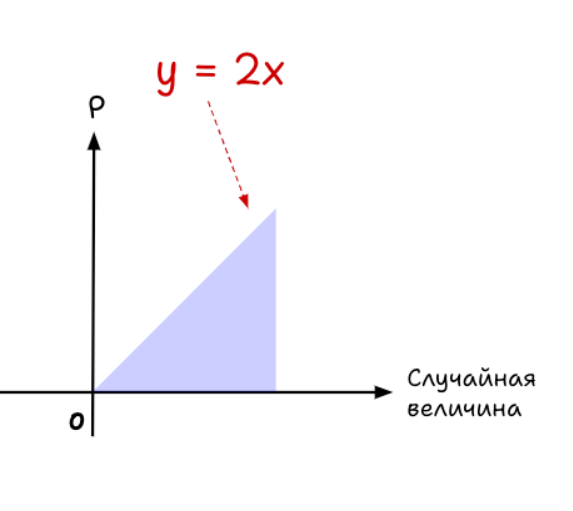

**6-1:** Вычислите вероятность попадания случайной величины в интервал от 0 до 0.5 включительно.

**6-2:** Запишите функцию вероятности (CDF) этого распределения.

**Задание 8\*\***


В задании 5 подберите прямую из множества **всех** прямых на плоскости, используя матричное решение метода наименьших квадратов: $w_{min} = (X^TX)^{-1}X^Ty$.

In [ ]:
from sympy import Matrix

X = Matrix([-3, 2, 5])
y = Matrix([2, 2, -3])

w_min = (X.T @ X).inv() @ X.T @ y

w_min

⎡-17 ⎤
⎢────⎥
⎣ 38 ⎦